In [1]:
from scripts.train_vbe_kfold import train_vbe
import torch
import matplotlib.pyplot as plt
from torch import Tensor

In [2]:
t = torch.rand(100) * 4 * torch.pi
data = torch.stack([t, t.sin()], dim=-1)
dmat_sqr = (data[:, None] - data).square().sum(-1)
dmat_sqr /= dmat_sqr.max()
dmat_sqr += 1e-3 # for numerical stability of the algorithm
vbe = train_vbe(dmat_sqr, "sine", epochs=500)

100%|██████████| 500/500 [02:28<00:00,  3.36it/s]


In [3]:
relevance = sorted(vbe.relevance_score(), reverse=True)[:10]
embedding = vbe.embed(dmat_sqr.to(vbe.device))

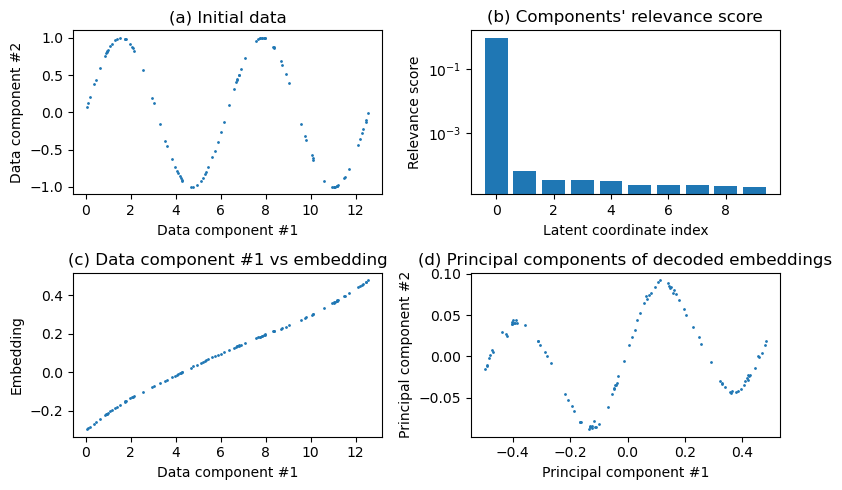

In [25]:
plt.figure(figsize=(8, 5))

plt.subplot(2, 2, 1)
plt.scatter(*data.T, s=1)
plt.xlabel("Data component #1")
plt.ylabel("Data component #2")
plt.title("(a) Initial data")


plt.subplot(2, 2, 2)
plt.bar(range(len(relevance)), relevance)
plt.xlabel("Latent coordinate index")
plt.ylabel("Relevance score")
plt.yscale("log")
plt.title(f"(b) Components' relevance score")


plt.subplot(2, 2, 3)
plt.scatter(t, embedding[:, 0], s=1)
plt.xlabel("Data component #1")
plt.ylabel("Embedding")
plt.title("(c) Data component #1 vs embedding")


plt.subplot(2, 2, 4)
plt.scatter(*PCA(n_components=2).fit_transform(vbe(dmat_sqr.to(vbe.device)).detach().cpu()).T, s=1)
plt.xlabel("Principal component #1")
plt.ylabel("Principal component #2")
plt.title("(d) Principal components of decoded embeddings")


plt.tight_layout()
plt.savefig("sine_graphs.pdf")
plt.show()

In [5]:
from sklearn.decomposition import PCA

In [6]:
x = vbe(dmat_sqr.to(vbe.device)).detach().cpu()

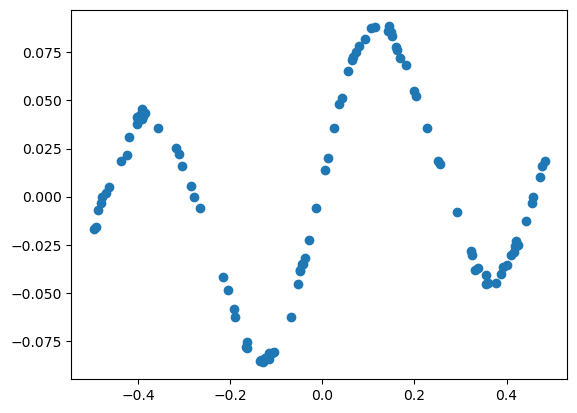

In [7]:
pca = PCA()

plt.scatter(*pca.fit_transform(x)[:, :2].T)

In [8]:
pca.explained_variance_ratio_

array([9.58972912e-01, 2.81952119e-02, 5.37522841e-03, 1.97159054e-03,
       5.72073790e-04, 3.75106613e-04, 3.12953586e-04, 2.89007998e-04,
       2.84744371e-04, 2.49799057e-04, 2.35997681e-04, 2.16431151e-04,
       2.01385932e-04, 1.87231361e-04, 1.84984023e-04, 1.72659938e-04,
       1.62179669e-04, 1.53052591e-04, 1.40746631e-04, 1.25231587e-04,
       1.15669520e-04, 1.09312889e-04, 9.91911747e-05, 9.72712718e-05,
       9.51430022e-05, 8.84875986e-05, 8.39604922e-05, 7.82016507e-05,
       7.54474573e-05, 7.07408814e-05, 6.89265712e-05, 6.29398413e-05,
       5.48484963e-05, 5.16993554e-05, 5.08566646e-05, 4.74080844e-05,
       4.42308040e-05, 4.18670065e-05, 4.05968589e-05, 3.33382702e-05,
       3.03731517e-05, 2.87197570e-05, 2.57376351e-05, 2.35474402e-05,
       2.08578961e-05, 1.69253406e-05, 1.60612844e-05, 1.50843586e-05,
       1.36658785e-05, 8.08771985e-06, 5.34120122e-06, 2.75654382e-06,
       1.91586374e-06, 1.35476113e-06, 9.04516579e-07, 5.40254349e-16,
      